# Phishing Website Detection using Machine Learning

## Notebook 03: Exploratory Data Analysis

### Objective

The objective of this notebook is to explore the cleaned phishing website dataset and understand the distribution, relationships, and characteristics of the input features.

The insights obtained from this analysis will help guide feature engineering and model development in the subsequent notebooks.

---


## 1. Import Required Libraries

Import the libraries required for data analysis and visualization.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Cleaned Dataset

Load the cleaned dataset generated in the previous notebook.

In [2]:
df = pd.read_csv("../dataset/cleaned_phishing_dataset.csv")

## 3. Dataset Overview

Display the shape of the dataset and inspect the first few records before starting the exploratory analysis.

In [3]:
df.shape

(4129, 75)

In [4]:
df.head()

,num_dots_url,num_hyph_url,num_underline_url,num_slash_url,num_questionmark_url,num_equal_url,at_sign_url,num_and_url,num_exclamation_url,num_space_url,...,tilde_param,num_comma_param,num_plus_param,num_asterisk_param,num_dollar_param,num_percent_param,length_param,tld_in_param,num_param,phishing
0,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,5,1,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Interpretation

- The cleaned dataset contains only unique observations.
- The dataset is ready for exploratory analysis.
- The following sections will focus on understanding the characteristics of the input features.

---

## 4. Understand Feature Types

Analyze the number of unique values in each feature to identify binary, discrete, and continuous variables. This helps in selecting appropriate visualization techniques for the exploratory analysis.

In [11]:
# Number of unique values in each feature
unique_values = df.nunique().sort_values()

unique_values


dom_in_ip              2
server_client_dom      2
num_underline_dom      2
email_in_url           2
at_sign_file           2
                    ... 
length_dom            65
length_file           78
length_path          153
length_param         266
length_url           350
Length: 75, dtype: int64

### Interpretation

- The dataset contains a combination of binary and numerical features.
- Several features have only **2 unique values**, indicating binary variables.
- Some features contain multiple discrete or continuous values, such as URL length and path length.
- Since the dataset includes different feature types, different visualization techniques will be used during the exploratory analysis.

---

## 5. Target Variable Distribution

Visualize the distribution of phishing and legitimate websites in the cleaned dataset.

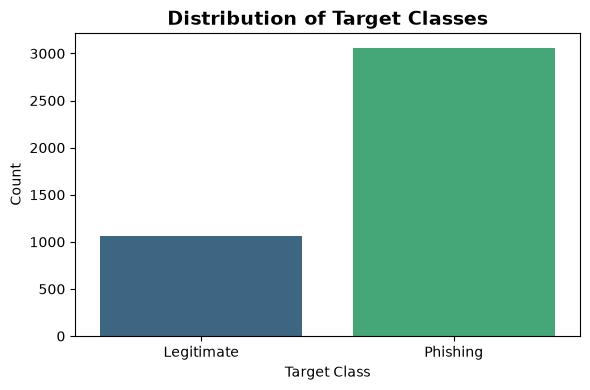

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="phishing",
    hue="phishing",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Target Classes", fontsize=14, fontweight="bold")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.xticks([0,1],["Legitimate","Phishing"])

plt.tight_layout()
plt.show()

### Interpretation

- The cleaned dataset contains both legitimate and phishing websites.
- The class distribution is no longer balanced after duplicate removal.
- This imbalance should be considered during model development and evaluation.

---

## 6. Feature Correlation with the Target Variable

**Question:** Which input features have the strongest relationship with phishing website detection?

Measure the correlation of each feature with the target variable to identify the features that are most relevant for the prediction task.

In [17]:
correlation = df.corr(numeric_only=True)["phishing"].drop("phishing")

correlation = correlation.abs().sort_values(ascending=False)

top_features = correlation.head(15)

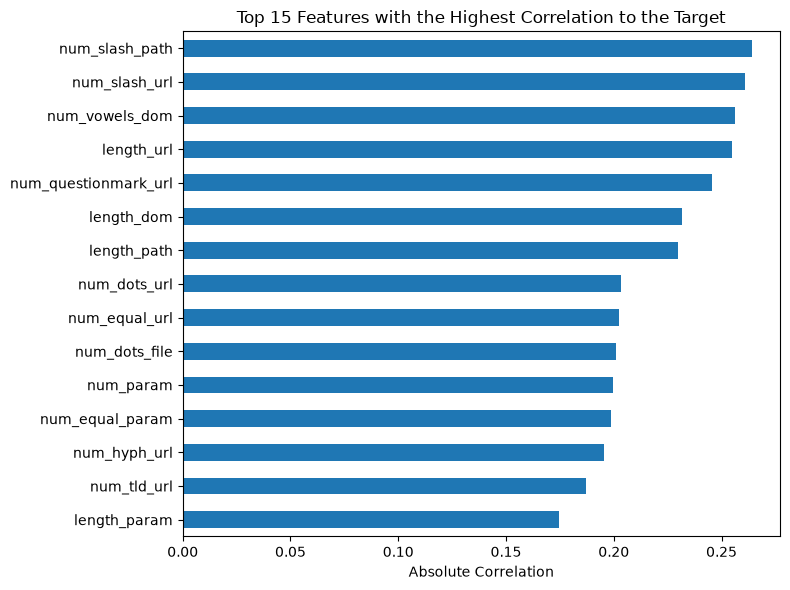

In [20]:
plt.figure(figsize=(8,6))

top_features.sort_values().plot(kind="barh")

plt.title("Top 15 Features with the Highest Correlation to the Target")
plt.xlabel("Absolute Correlation")

plt.tight_layout()

plt.show()

### Interpretation

- The most strongly correlated features are related to the structural characteristics of a URL, such as the number of slashes, URL length, domain length, and the occurrence of special characters.
- The highest absolute correlation is approximately **0.26**, indicating that no single feature is a strong predictor of phishing websites on its own.
- This suggests that phishing detection relies on the combined contribution of multiple features rather than a single dominant characteristic.
- The identified features will be explored further in the subsequent sections of this notebook.

---

## 7. Correlation Analysis

**Question:** How are the input features related to each other?

Analyze the relationships between the input features using a correlation matrix. This helps identify groups of highly correlated features that may contain similar information and can be considered during feature engineering.

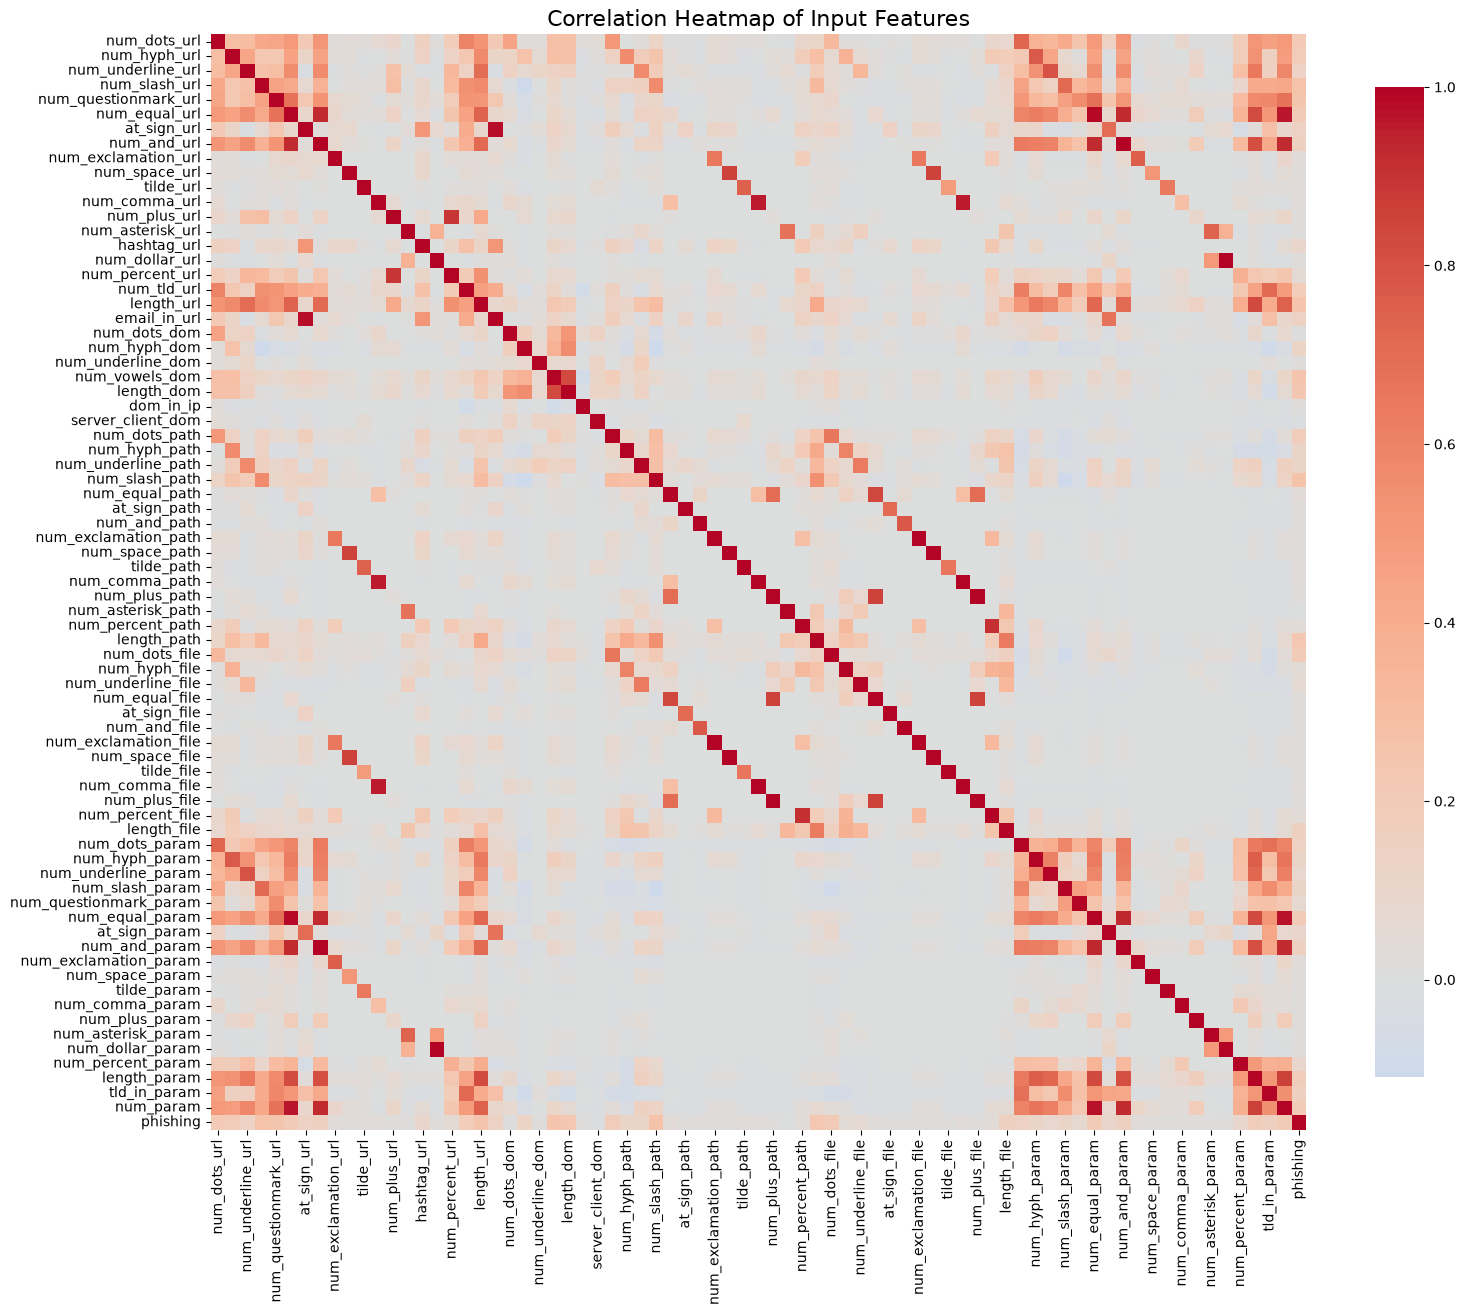

In [19]:
plt.figure(figsize=(16, 14))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Input Features", fontsize=16)

plt.tight_layout()

plt.show()

### Interpretation

- Most feature pairs exhibit weak to moderate correlations, indicating that many features capture distinct characteristics of a website.
- A few groups of features show stronger positive correlations, suggesting that they describe similar URL or webpage properties.
- The correlation heatmap provides an overall view of feature relationships and helps identify potential redundancy.
- Highly correlated feature pairs will be examined in the next section to determine whether any features can be removed during feature engineering.

---

## 8. Highly Correlated Feature Pairs

**Question:** Which input features are highly correlated and may provide redundant information?

Identify pairs of features with high correlation coefficients. These feature pairs will be considered during feature engineering to determine whether any redundant features should be removed.

In [22]:
corr_matrix = df.corr(numeric_only=True).abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper_triangle.stack()
                  .reset_index()
)

high_corr.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr = high_corr[
    high_corr["Correlation"] > 0.80
].sort_values(
    by="Correlation",
    ascending=False
)

high_corr.head(15)

,Feature 1,Feature 2,Correlation
1194,num_dollar_url,num_dollar_param,1.000000
2674,num_space_path,num_space_file,1.000000
2826,num_comma_path,num_comma_file,1.000000
2902,num_plus_path,num_plus_file,1.000000
2598,num_exclamation_path,num_exclamation_file,1.000000
587,num_and_url,num_and_param,0.998705
435,num_equal_url,num_equal_param,0.990648
469,at_sign_url,email_in_url,0.975731
4573,num_equal_param,num_param,0.973230
448,num_equal_url,num_param,0.963910


### Note: 
A threshold of **0.80** is commonly used to identify strongly correlated feature pairs that may provide redundant information.

### Interpretation

- Several feature pairs exhibit very high positive correlations (greater than 0.80), indicating that they capture similar information.
- Some feature pairs, such as `num_dollar_url`–`num_dollar_param` and `num_space_path`–`num_space_file`, have perfect or near-perfect correlations.
- Highly correlated features may introduce redundancy in the dataset and will be carefully evaluated during the feature engineering stage.
- At this stage, no features are removed. The purpose of this analysis is to identify potential candidates for feature selection in the next notebook.

## 9. Distribution of URL Length Features

**Question:** How are the most important URL length-related features distributed across the dataset?

Automatically identify the important length-related features from the previously selected top correlated features and visualize their distributions.

In [25]:
important_features = top_features.index.tolist()

In [28]:
# Select important length-related features automatically
length_features = [
    feature for feature in important_features
    if feature.startswith("length")
]


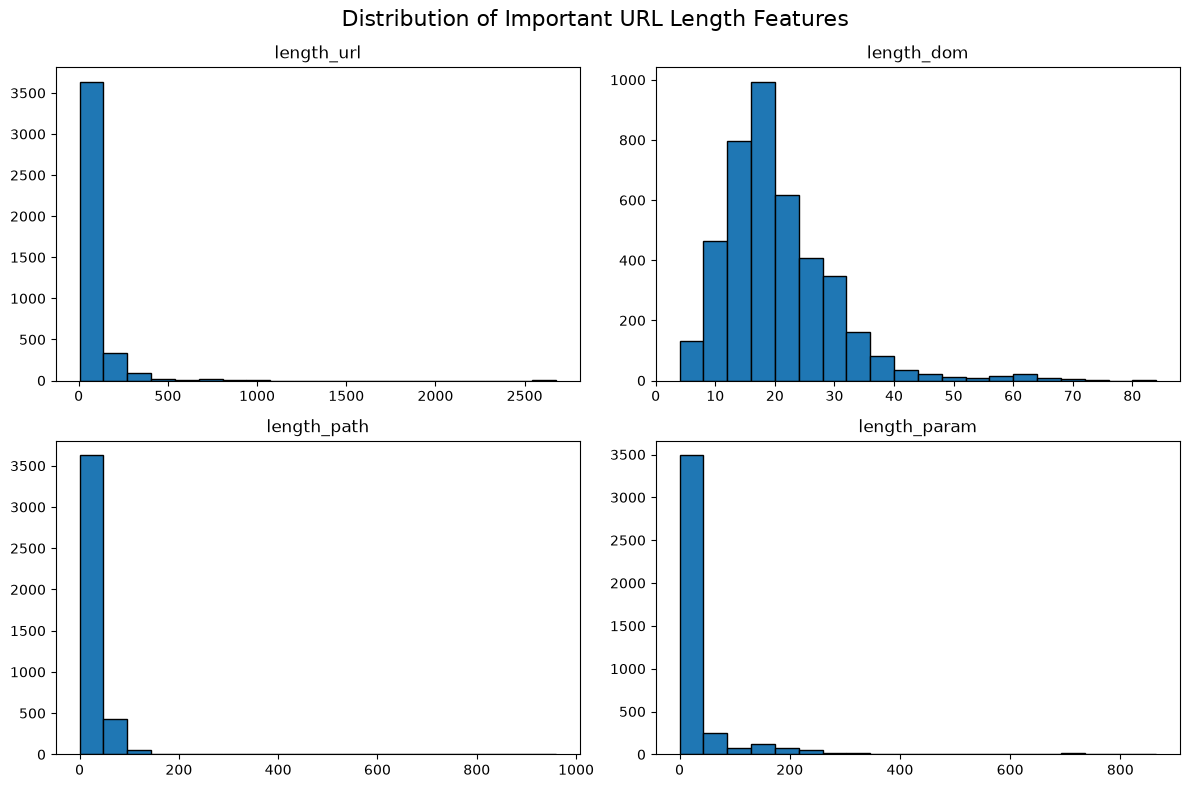

In [37]:
df[length_features].hist(
    figsize=(12,8),
    bins=20,
    edgecolor="black",
    grid=False
)

plt.suptitle("Distribution of Important URL Length Features", fontsize=16)

plt.tight_layout()

plt.show()

### Interpretation

- The distributions of the important URL length-related features show variations in URL structure across the dataset.
- Some features exhibit skewed distributions, indicating that certain URL lengths occur more frequently than others.
- These observations provide an initial understanding of the dataset and will be further explored by comparing phishing and legitimate websites in the next section.

---

## 10. Distribution of URL Count Features

**Question:** How are the most important URL count-based features distributed across the dataset?

Automatically identify the important count-based features from the previously selected top correlated features and visualize their frequency distributions.

In [30]:
# Select important count-based features automatically
count_features = [
    feature for feature in important_features
    if feature.startswith("num")
]

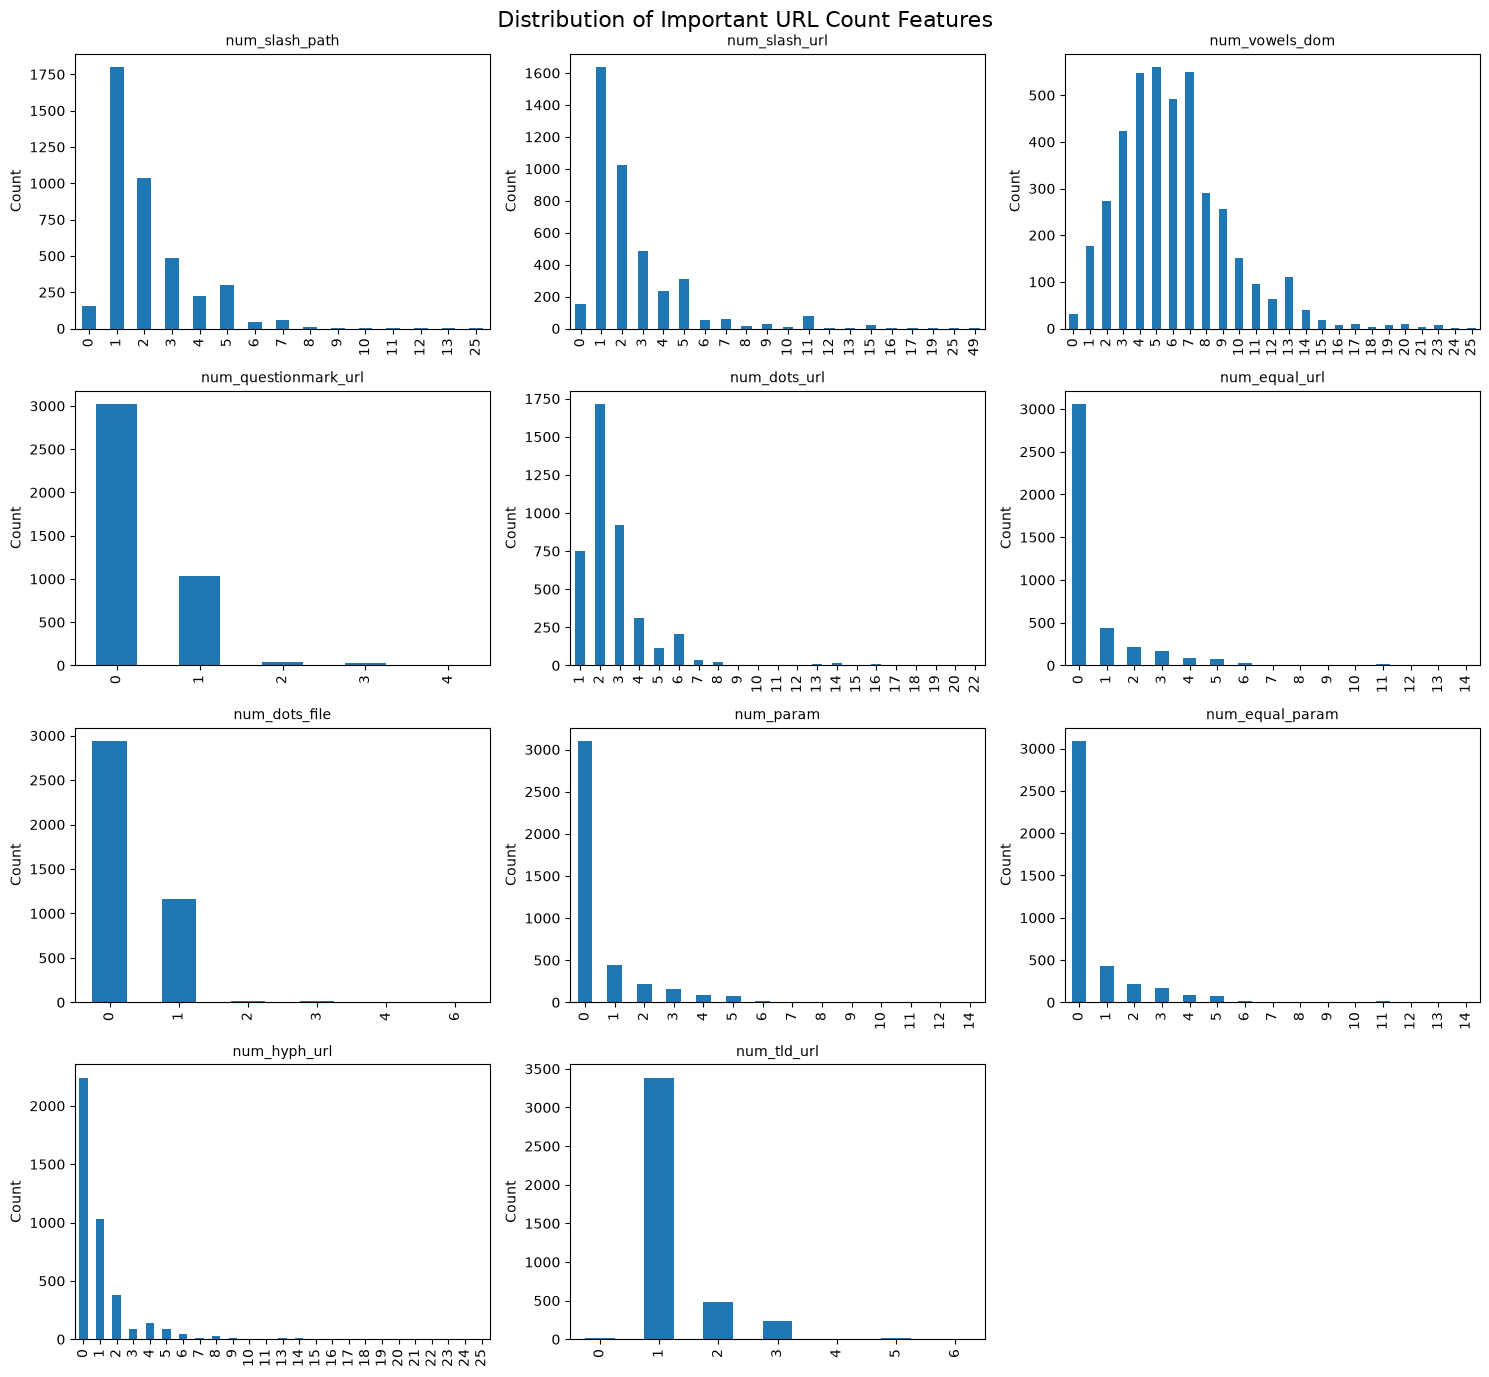

In [31]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, feature in enumerate(count_features):
    df[feature].value_counts().sort_index().plot(
        kind="bar",
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Remove unused subplot
fig.delaxes(axes[-1])

plt.suptitle("Distribution of Important URL Count Features", fontsize=16)

plt.tight_layout()

plt.show()

### Interpretation

- Most count-based features contain relatively small integer values, indicating that URL components and special characters occur with limited frequency.
- The distributions differ across features, suggesting that certain URL characteristics appear more frequently than others.
- These count-based features will be further analyzed with respect to the target variable in the next section.

---

## 11. Target-wise Comparison of Important Features

**Question:** How do the most important features differ between legitimate and phishing websites?

Compare the distributions of the important features across the two target classes to identify characteristics that distinguish phishing websites from legitimate websites.

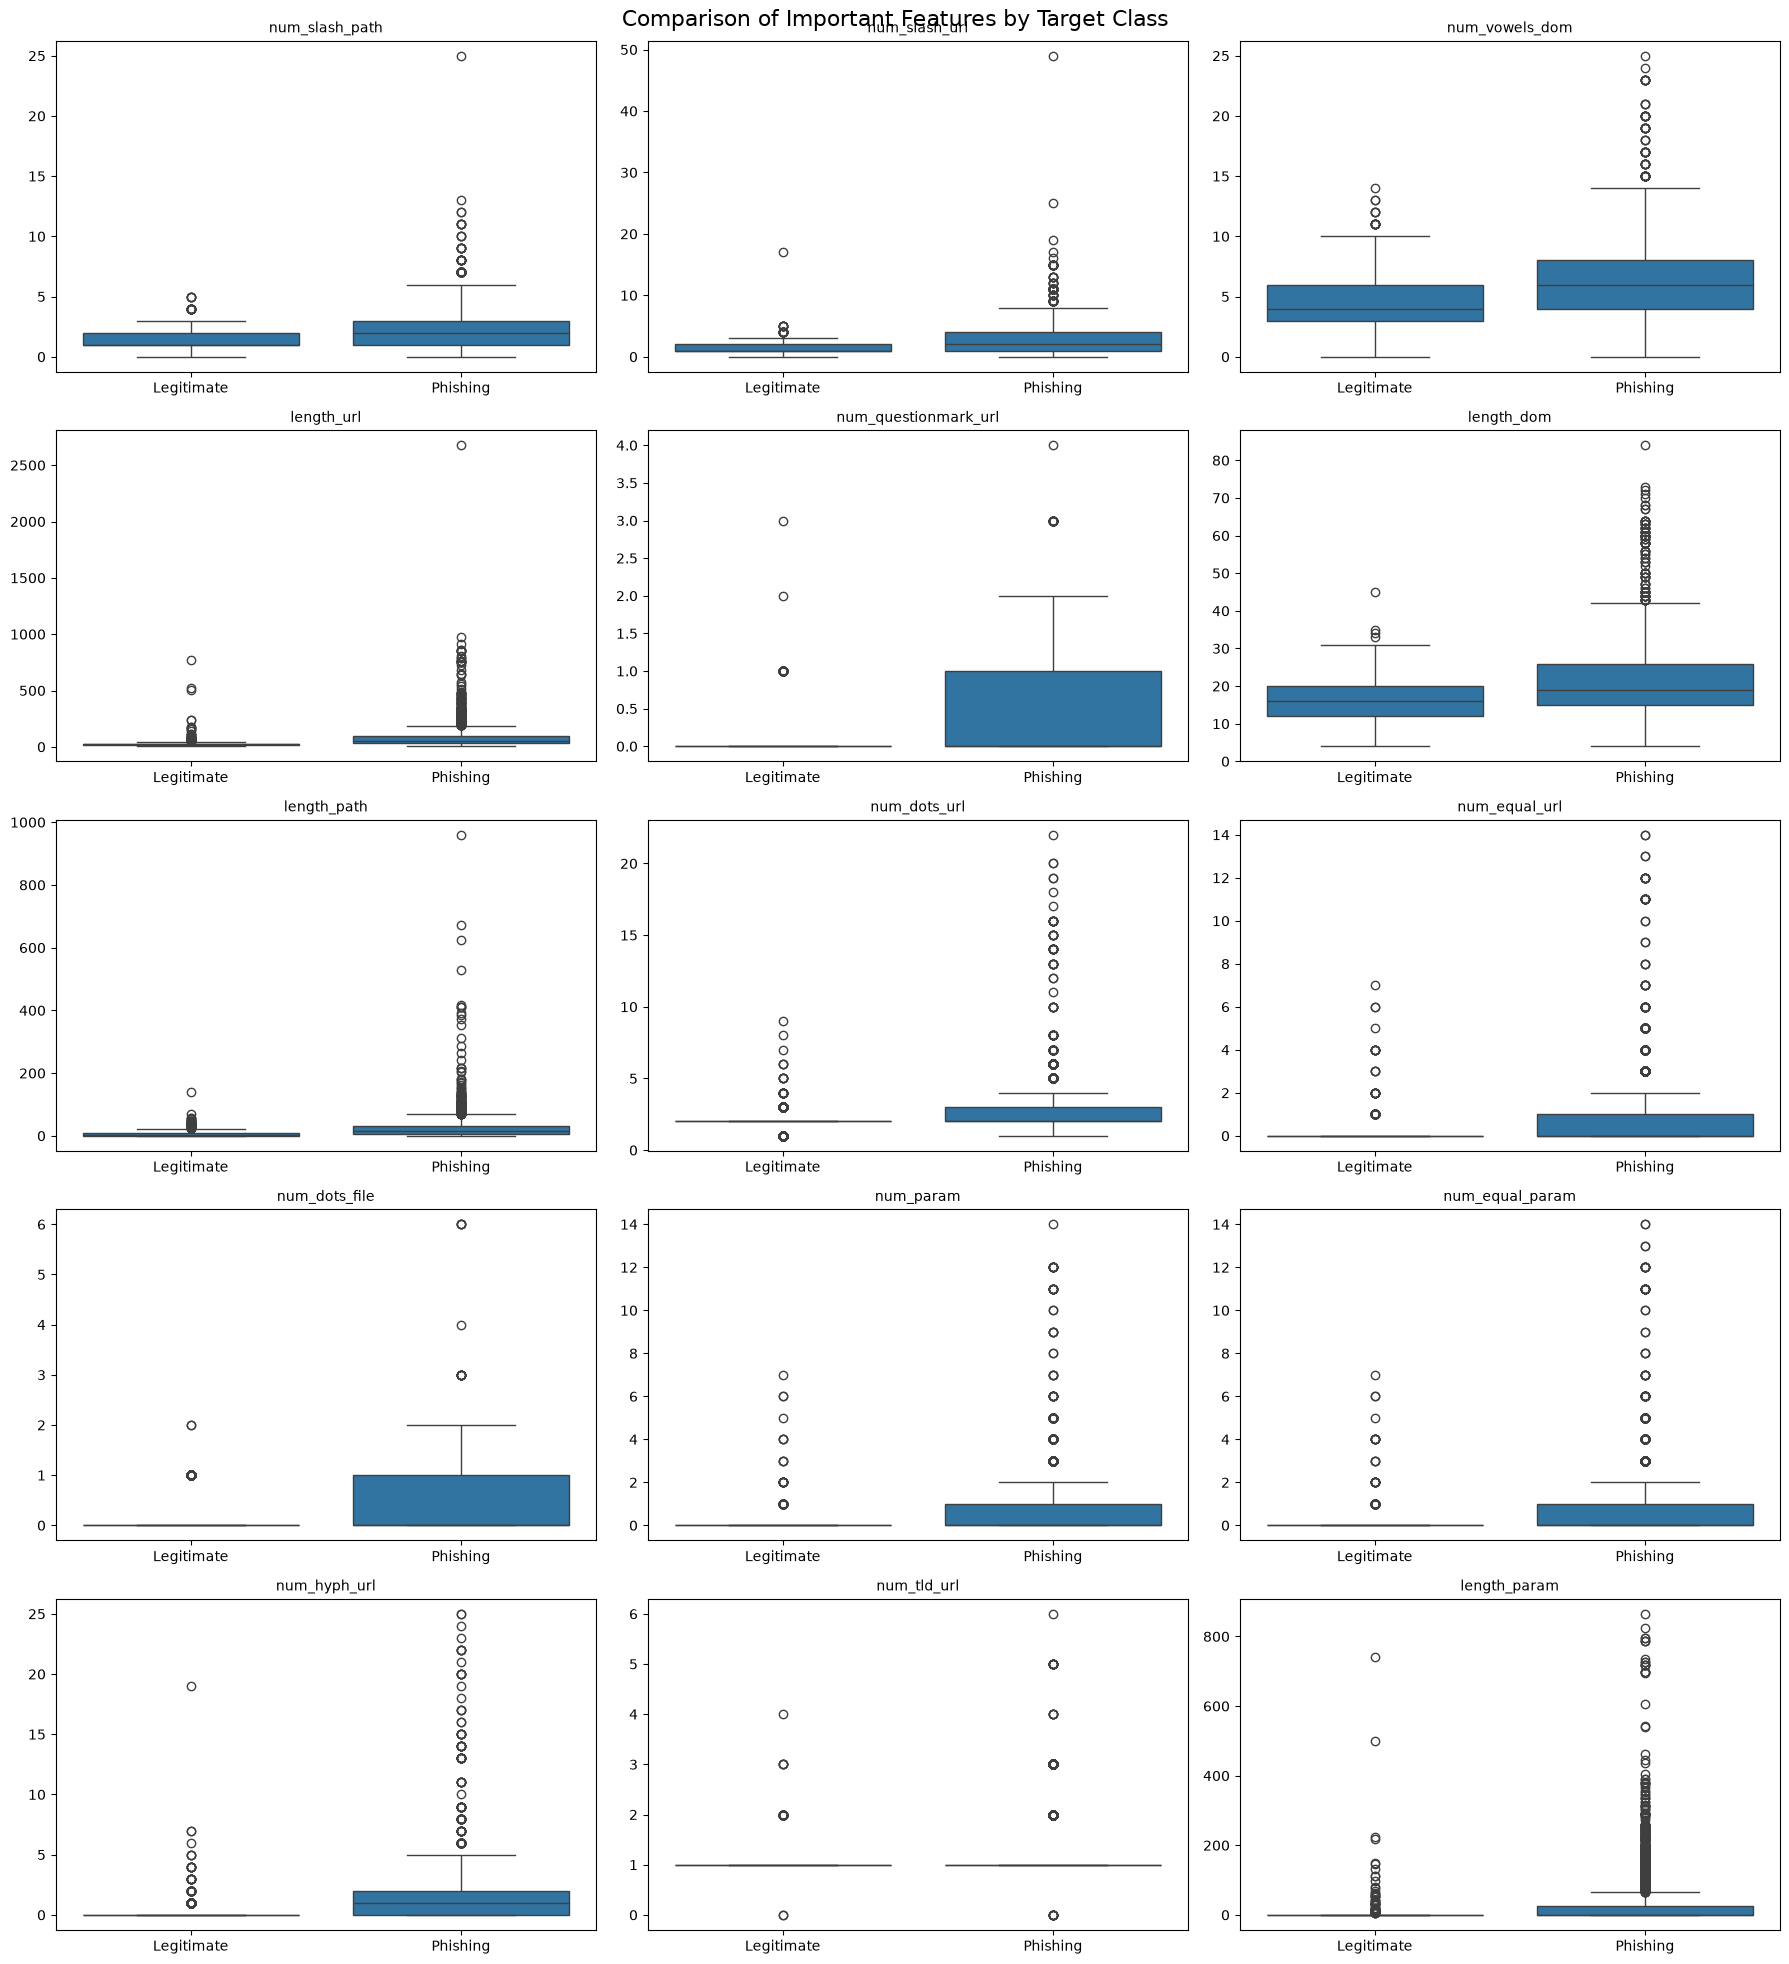

In [36]:
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, feature in enumerate(important_features):
    sns.boxplot(
        data=df,
        x="phishing",
        y=feature,
        order=[0, 1],
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Legitimate", "Phishing"])

# Remove unused subplot
for j in range(len(important_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Comparison of Important Features by Target Class", fontsize=16)

plt.tight_layout()
plt.show()

### Interpretation

- Phishing websites generally exhibit higher values for several important features, including URL length, path length, domain length, and the counts of special characters.
- Many phishing-related features display a wider spread and a larger number of outliers, indicating greater variability in malicious URLs.
- Legitimate websites tend to have more compact distributions with lower median values for most of the important features.
- These observations suggest that phishing websites often contain longer URLs and a greater number of URL components or special characters, making these features valuable for distinguishing between the two classes.

---

## 12. Key Findings

-  URL length and structural characteristics are among the most informative indicators for phishing detection.
- Several feature pairs exhibit strong positive correlations, indicating potential redundancy.
- Phishing websites generally contain longer URLs and more URL components than legitimate websites.
- The identified feature relationships will guide the feature engineering stage.


## 13. Conclusion

The exploratory data analysis provided valuable insights into the characteristics of the phishing website dataset. Important features were identified through correlation analysis, feature relationships were examined, and meaningful differences between phishing and legitimate websites were observed.

The findings from this notebook will guide the next stage of the project, **Feature Engineering**, where feature redundancy will be addressed and suitable feature selection techniques will be applied before building machine learning models.